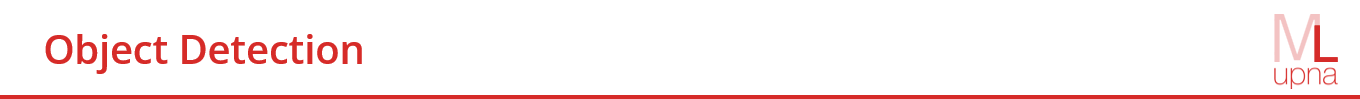

In this practical exercise, we will explore the field of <span style="color:#D52B29">Object Detection</span>. We will begin by downloading the <span style="color:#D52B29">Pascal VOC dataset</span> and inspecting a few random samples to become familiar with the <span style="color:#D52B29">object detection dataset format</span>.

Next, we will approach the task using <span style="color:#D52B29">two-stage models</span>. The first step will involve the <span style="color:#D52B29">region proposal stage</span>, where we will replicate the <span style="color:#D52B29">selective search algorithm</span> used in the original <span style="color:#D52B29">R-CNN</span> paper. After that, we will <span style="color:#D52B29">fine-tune a Faster R-CNN model</span> from <span style="color:#D52B29">torchvision</span>.

Once the two-stage models are covered, we will move to <span style="color:#D52B29">one-stage models</span>, focusing on the <span style="color:#D52B29">FCOS</span> architecture. Finally, the exercise will conclude with one of the most well-known model families in object detection — <span style="color:#D52B29">YOLO</span> — where we will <span style="color:#D52B29">fine-tune the model</span> using the <span style="color:#D52B29">Ultralytics library</span>.

## <span style="color:#D52B29">The PASCAL VOC Dataset</span>

We will use the <span style='color:#D52B29'>PASCAL VOC (Visual Object Classes)</span> dataset, a classic and much lighter alternative to COCO for object detection tasks. Here is the essential layout inside the main VOC2012/ directory:

```
VOCdevkit/
└── VOC2012/
    ├── Annotations/         # XML files with object labels for each image
    ├── ImageSets/           # Text files defining training/validation splits
    │   └── Main/
    ├── JPEGImages/          # All the .jpg image files
    ├── SegmentationClass/   # Pixel-wise masks for semantic segmentation
    └── SegmentationObject/  # Pixel-wise masks for instance segmentation
```

- Annotations/: This folder contains .xml files, one for each image. Each file details all the objects in the corresponding image, including their class names (e.g., 'car') and their bounding box coordinates.

- JPEGImages/: This is where all the actual image files are stored in .jpg format.

- ImageSets/Main/: This crucial subfolder contains text files like train.txt and val.txt. These files simply list the filenames of the images that belong to the training and validation sets, respectively. This is how the dataset is split for model training and evaluation.

- SegmentationClass/ & SegmentationObject/: These folders contain ground-truth segmentation masks as .png images, used for more advanced pixel-level tasks beyond simple object detection.

In [1]:
# # Download from Huggingface
# !wget -q --show-progress https://huggingface.co/datasets/cayala/pascal_voc/resolve/main/VOC2012.zip

# # Extract to folder
# !unzip -q VOC2012.zip -d VOC2012

# # Remove the zip file
# !rm VOC2012.zip

VOC2012.zip         100%[===================>]   1,81G   104MB/s    in 18s     
replace VOC2012/VOC2012/Annotations/2007_000027.xml? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C


In [5]:
import glob
import pandas as pd
import os

# List images
images = glob.glob('./VOC2012/VOC2012/JPEGImages/*')
df = pd.DataFrame(images, columns=['image_fp'])

# Assign corresponding labels
df['ann_fp'] = df.image_fp.apply(lambda x : x.replace('/JPEGImages/', '/Annotations/').replace('.jpg', '.xml'))

# Get splits
with open('./VOC2012/VOC2012/ImageSets/Main/train.txt', 'r') as f: train_ids = [line.strip() for line in f]
with open('./VOC2012/VOC2012/ImageSets/Main/val.txt', 'r') as f: val_ids = [line.strip() for line in f]
df['image_id'] = df['image_fp'].apply(lambda x: os.path.splitext(os.path.basename(x))[0])

def get_set(image_id):
    if image_id in train_ids:
        return 'train'
    elif image_id in val_ids:
        return 'val'
    return 'test' # Should not happen for this dataset

df['set'] = df['image_id'].apply(get_set)

df.head()

,image_fp,ann_fp,image_id,set
0,./VOC2012/VOC2012/JPEGImages/2007_001185.jpg,./VOC2012/VOC2012/Annotations/2007_001185.xml,2007_001185,test
1,./VOC2012/VOC2012/JPEGImages/2007_007417.jpg,./VOC2012/VOC2012/Annotations/2007_007417.xml,2007_007417,test
2,./VOC2012/VOC2012/JPEGImages/2007_009533.jpg,./VOC2012/VOC2012/Annotations/2007_009533.xml,2007_009533,test
3,./VOC2012/VOC2012/JPEGImages/2008_000356.jpg,./VOC2012/VOC2012/Annotations/2008_000356.xml,2008_000356,train
4,./VOC2012/VOC2012/JPEGImages/2008_001764.jpg,./VOC2012/VOC2012/Annotations/2008_001764.xml,2008_001764,val


Now lets build our Pytorch Dataset class. The most critical task this class performs is handling images of different sizes. Inside `__getitem__`, it first <span style='color:#D52B29'>resizes the image</span> to a consistent shape. Then, to ensure the labels remain correct, it calculates scaling factors (<span style='color:#D52B29'>w_scale</span> and <span style='color:#D52B29'>h_scale</span>) and uses them to <span style='color:#D52B29'>manually scale the bounding box coordinates</span> from the XML file.

The class ultimately returns a processed image tensor and a corresponding <span style='color:#D52B29'>target</span> dictionary, perfectly formatted for use with a PyTorch <span style='color:#D52B29'>DataLoader</span>.

In [6]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import xml.etree.ElementTree as ET

In [8]:
import numpy as np
import os
import cv2

# 1. Define the VOC Classes (Order matters!)
classes = (
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat',
    'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person',
    'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
)

# 2. Helper function to convert your DataFrame to MMDetection format
def convert_to_mmdet_format(dataframe, classes):
    data_infos = []
    
    # Map class names to integers (e.g., 'aeroplane' -> 0)
    cat2label = {k: i for i, k in enumerate(classes)}
    
    # Group by image so we can collect all objects for one image
    # Assuming your DF has columns: 'image_path', 'xmin', 'ymin', 'xmax', 'ymax', 'label', 'set'
    grouped = dataframe.groupby('image_fp')
    
    for img_path, group in grouped:
        # Get image dimensions (Assuming you have width/height in DF, 
        # otherwise we might need to load the image to check, which is slow)
        # If your DF doesn't have width/height, we usually load it once here.
        # For this example, let's assume you can access them or load them.
       
        img = cv2.imread(img_path)
        h, w, _ = img.shape
        
        filename = os.path.basename(img_path)
        
        # Base info for the image
        info = {
            'img_path': img_path,
            'height': h,
            'width': w,
            'instances': []
        }
        
        # Add the objects (bounding boxes)
        for _, row in group.iterrows():
            bbox = [row['xmin'], row['ymin'], row['xmax'], row['ymax']]
            label = cat2label[row['label']]
            
            info['instances'].append({
                'bbox': bbox,
                'bbox_label': label,
                'ignore_flag': 0 # Required by MMDetection 3.x
            })
            
        data_infos.append(info)
        
    return data_infos

# 3. Create the Training and Validation Lists
# (This replaces creating the Dataset object)
print("Converting DataFrame to MMDetection format...")
train_list = convert_to_mmdet_format(df.query('set == "train"'), classes)
val_list = convert_to_mmdet_format(df.query('set == "val"'), classes)

print(f"MMDetection Training Samples: {len(train_list)}")
print(f"MMDetection Validation Samples: {len(val_list)}")

# 4. Inspect Sample 0 (Just to verify)
print("\nSample 0 structure:")
print(train_list[0])

Converting DataFrame to MMDetection format...


KeyError: 'xmin'

In [9]:
# VOC Classes taken from the paper
VOC_CLASSES = (
    "aeroplane", "bicycle", "bird", "boat", "bottle", "bus", "car", "cat",
    "chair", "cow", "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
)

In [15]:
!uv pip install mmengine
!uv pip install mmdet
!uv pip install mmcv

Using Python 3.13.7 environment at: /home/alumno/py313ml/.venv
Audited 1 package in 5ms
Using Python 3.13.7 environment at: /home/alumno/py313ml/.venv
Audited 1 package in 5ms
Using Python 3.13.7 environment at: /home/alumno/py313ml/.venv
  × Failed to build `mmcv==2.2.0`                                                   
  ├─▶ The build backend returned an error
  ╰─▶ Call to `setuptools.build_meta:__legacy__.build_wheel` failed (exit
      status: 1)

      [stdout]
      Skip building ext ops due to the absence of torch.

      [stderr]
      <string>:5: UserWarning: pkg_resources is deprecated as an API.
      See https://setuptools.pypa.io/en/latest/pkg_resources.html. The
      pkg_resources package is slated for removal as early as 2025-11-30.
      Refrain from using this package or pin to Setuptools<81.
      Traceback (most recent call last):
        File "<string>", line 14, in <module>
          requires = get_requires_for_build({})
        File
      "/home/alumno/.cache/u

In [14]:
# We must import from MMDetection, not torch.utils.data
from mmengine.dataset import BaseDataset
from mmdet.registry import DATASETS
import numpy as np
import xml.etree.ElementTree as ET
import os
import cv2

# Register this class so the Config can find it later using type='VOCDataFrameDataset'
@DATASETS.register_module()
class VOCDataFrameDataset(BaseDataset):
    """
    Custom Dataset for MMDetection that reads from your pandas DataFrame.
    """
    
    # 1. Initialize with the DataFrame and Classes
    def __init__(self, df, classes, **kwargs):
        self.df = df
        # OpenMMLab uses 'metainfo' to store class names
        self.metainfo = {'classes': classes}
        super().__init__(**kwargs)

    # 2. IMPLEMENT THIS INSTEAD OF __getitem__
    # MMDetection calls this ONCE at the start to index all your data.
    def load_data_list(self):
        data_list = []
        
        # Create map: 'aeroplane' -> 0, 'bicycle' -> 1...
        class_to_int = {cls: i for i, cls in enumerate(self.metainfo['classes'])}
        
        # Iterate over your DataFrame rows
        for idx, row in self.df.iterrows():
            image_fp = row['image_fp']
            ann_fp = row['ann_fp']
            
            # --- PARSE IMAGE INFO ---
            # We need height/width. 
            # (Optimization: If your DF has width/height cols, use them! It's faster than reading the file)
            img = cv2.imread(image_fp)
            if img is None: continue
            height, width = img.shape[:2]
            
            # --- PARSE ANNOTATION (XML) ---
            tree = ET.parse(ann_fp)
            root = tree.getroot()
            
            instances = []
            for obj in root.findall('object'):
                class_name = obj.find('name').text
                if class_name not in class_to_int:
                    continue
                
                label = class_to_int[class_name]
                bndbox = obj.find('bndbox')
                
                # Extract coordinates
                # Note: MMDetection expects [x1, y1, x2, y2]
                xmin = float(bndbox.find('xmin').text)
                ymin = float(bndbox.find('ymin').text)
                xmax = float(bndbox.find('xmax').text)
                ymax = float(bndbox.find('ymax').text)
                
                instances.append({
                    'bbox': [xmin, ymin, xmax, ymax],
                    'bbox_label': label,
                    'ignore_flag': 0
                })
            
            # --- CREATE DATA DICT ---
            # This specific structure is required by MMDetection
            data_info = {
                'img_path': image_fp,
                'img_id': idx,
                'height': height,
                'width': width,
                'instances': instances
            }
            
            data_list.append(data_info)
            
        return data_list

ModuleNotFoundError: No module named 'mmcv'

In [ ]:
from mmengine.config import Config

# 1. Define the transformations (Data Pipeline)
# MMDetection pipelines are defined as a list of dicts.
train_pipeline = [
    dict(type='LoadImageFromFile'),  # Reads image from disk
    dict(type='LoadAnnotations', with_bbox=True), # Reads bboxes from our dataset class
    dict(type='Resize', scale=(384, 384), keep_ratio=False), # Resize to fixed size
    dict(type='RandomFlip', prob=0.5), # Data Augmentation
    dict(type='PackDetInputs') # Formats data for the model
]

test_pipeline = [
    dict(type='LoadImageFromFile'),
    dict(type='LoadAnnotations', with_bbox=True),
    dict(type='Resize', scale=(384, 384), keep_ratio=False),
    dict(type='PackDetInputs')
]

# 2. Build the Config
# We start with a base config structure
cfg = Config(dict(
    # --- Model Configuration (We'll use Faster R-CNN as a base) ---
    model=dict(
        type='FasterRCNN',
        data_preprocessor=dict(
            type='DetDataPreprocessor',
            mean=[123.675, 116.28, 103.53], # ImageNet mean
            std=[58.395, 57.12, 57.375],    # ImageNet std
            bgr_to_rgb=True,
            pad_size_divisor=32),
        backbone=dict(
            type='ResNet',
            depth=50,
            num_stages=4,
            out_indices=(0, 1, 2, 3),
            frozen_stages=1,
            norm_cfg=dict(type='BN', requires_grad=True),
            norm_eval=True,
            style='pytorch',
            init_cfg=dict(type='Pretrained', checkpoint='torchvision://resnet50')),
        neck=dict(
            type='FPN',
            in_channels=[256, 512, 1024, 2048],
            out_channels=256,
            num_outs=5),
        rpn_head=dict(
            type='RPNHead',
            in_channels=256,
            feat_channels=256,
            anchor_generator=dict(
                type='AnchorGenerator',
                scales=[8],
                ratios=[0.5, 1.0, 2.0],
                strides=[4, 8, 16, 32, 64]),
            bbox_coder=dict(
                type='DeltaXYWHBBoxCoder',
                target_means=[.0, .0, .0, .0],
                target_stds=[1.0, 1.0, 1.0, 1.0]),
            loss_cls=dict(
                type='CrossEntropyLoss', use_sigmoid=True, loss_weight=1.0),
            loss_bbox=dict(type='L1Loss', loss_weight=1.0)),
        roi_head=dict(
            type='StandardRoIHead',
            bbox_roi_extractor=dict(
                type='SingleRoIExtractor',
                roi_layer=dict(type='RoIAlign', output_size=7, sampling_ratio=0),
                out_channels=256,
                featmap_strides=[4, 8, 16, 32]),
            bbox_head=dict(
                type='Shared2FCBBoxHead',
                in_channels=256,
                fc_out_channels=1024,
                roi_feat_size=7,
                num_classes=20, # VOC has 20 classes
                bbox_coder=dict(
                    type='DeltaXYWHBBoxCoder',
                    target_means=[0., 0., 0., 0.],
                    target_stds=[0.1, 0.1, 0.2, 0.2]),
                reg_class_agnostic=False,
                loss_cls=dict(
                    type='CrossEntropyLoss', use_sigmoid=False, loss_weight=1.0),
                loss_bbox=dict(type='L1Loss', loss_weight=1.0))),
        # Model training and testing settings
        train_cfg=dict(
            rpn=dict(
                assigner=dict(
                    type='MaxIoUAssigner',
                    pos_iou_thr=0.7,
                    neg_iou_thr=0.3,
                    min_pos_iou=0.3,
                    match_low_quality=True,
                    ignore_iof_thr=-1),
                sampler=dict(
                    type='RandomSampler',
                    num=256,
                    pos_fraction=0.5,
                    neg_pos_ub=-1,
                    add_gt_as_proposals=False),
                allowed_border=-1,
                pos_weight=-1,
                debug=False),
            rpn_proposal=dict(
                nms_pre=2000,
                max_per_img=1000,
                nms=dict(type='nms', iou_threshold=0.7),
                min_bbox_size=0),
            rcnn=dict(
                assigner=dict(
                    type='MaxIoUAssigner',
                    pos_iou_thr=0.5,
                    neg_iou_thr=0.5,
                    min_pos_iou=0.5,
                    match_low_quality=False,
                    ignore_iof_thr=-1),
                sampler=dict(
                    type='RandomSampler',
                    num=512,
                    pos_fraction=0.25,
                    neg_pos_ub=-1,
                    add_gt_as_proposals=True),
                pos_weight=-1,
                debug=False)),
        test_cfg=dict(
            rpn=dict(
                nms_pre=1000,
                max_per_img=1000,
                nms=dict(type='nms', iou_threshold=0.7),
                min_bbox_size=0),
            rcnn=dict(
                score_thr=0.05,
                nms=dict(type='nms', iou_threshold=0.5),
                max_per_img=100)
        )),

    # --- Data Configuration ---
    # Here we use the custom class we defined in the previous cell!
    train_dataloader=dict(
        batch_size=4,
        num_workers=2,
        persistent_workers=True,
        sampler=dict(type='DefaultSampler', shuffle=True),
        dataset=dict(
            type='VOCDataFrameDataset', # <--- OUR CUSTOM CLASS
            df=df.query('set == "train"'),
            classes=classes, # variable from earlier cell
            pipeline=train_pipeline
        )
    ),
    val_dataloader=dict(
        batch_size=1,
        num_workers=2,
        persistent_workers=True,
        drop_last=False,
        sampler=dict(type='DefaultSampler', shuffle=False),
        dataset=dict(
            type='VOCDataFrameDataset', # <--- OUR CUSTOM CLASS
            df=df.query('set == "val"'),
            classes=classes,
            pipeline=test_pipeline
        )
    ),
    test_dataloader=dict(
        batch_size=1,
        num_workers=2,
        persistent_workers=True,
        drop_last=False,
        sampler=dict(type='DefaultSampler', shuffle=False),
        dataset=dict(
            type='VOCDataFrameDataset',
            df=df.query('set == "test"'), # Or val if no test set
            classes=classes,
            pipeline=test_pipeline
        )
    ),
    
    # --- Evaluator ---
    val_evaluator=dict(type='VOCMetric', metric='mAP', eval_mode='class_wise'),
    test_evaluator=dict(type='VOCMetric', metric='mAP', eval_mode='class_wise'),

    # --- Runtime Settings ---
    train_cfg=dict(type='EpochBasedTrainLoop', max_epochs=12, val_interval=1),
    val_cfg=dict(type='ValLoop'),
    test_cfg=dict(type='TestLoop'),
    
    param_scheduler=[
        dict(type='LinearLR', start_factor=0.001, by_epoch=False, begin=0, end=500),
        dict(type='MultiStepLR', begin=0, end=12, by_epoch=True, milestones=[8, 11], gamma=0.1)
    ],
    
    optim_wrapper=dict(
        type='OptimWrapper',
        optimizer=dict(type='SGD', lr=0.0025, momentum=0.9, weight_decay=0.0001)
    ),
    
    default_scope='mmdet',
    default_hooks=dict(
        timer=dict(type='IterTimerHook'),
        logger=dict(type='LoggerHook', interval=50),
        param_scheduler=dict(type='ParamSchedulerHook'),
        checkpoint=dict(type='CheckpointHook', interval=1),
        sampler_seed=dict(type='DistSamplerSeedHook'),
    ),
    
    env_cfg=dict(
        cudnn_benchmark=False,
        mp_cfg=dict(mp_start_method='fork', opencv_num_threads=0),
        dist_cfg=dict(backend='nccl'),
    ),
    
    vis_backends=[dict(type='LocalVisBackend')],
    visualizer=dict(
        type='DetLocalVisualizer',
        vis_backends=[dict(type='LocalVisBackend')],
        name='visualizer'),
    
    log_processor=dict(type='LogProcessor', window_size=50, by_epoch=True),
    
    work_dir='./work_dirs/voc_faster_rcnn'
))

print("✅ MMDetection Config created successfully.")

Now let's fetch a random batch from the DataLoader and use the visualization function to display the images with their corresponding ground truth bounding boxes overlaid.

**Visualize sample**

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import numpy as np

# 1. Fetch the first sample from the MMDetection-style list we created earlier
# (Remember: train_list is a list of dicts, not a PyTorch Dataset)
sample_info = train_list[0]

print(f"Sample Info Keys: {sample_info.keys()}")
print(f"Image Path: {sample_info['img_path']}")
print(f"Number of Objects: {len(sample_info['instances'])}")

# 2. Visualization Function
def show_mmdet_sample(sample_info, classes):
    """
    Visualizes a single sample dictionary in MMDetection format.
    """
    img_path = sample_info['img_path']
    instances = sample_info['instances']
    
    # Load image (OpenCV loads as BGR, convert to RGB)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(img)
    ax.set_title(f"Image ID: {sample_info['img_id']}")
    
    # Draw boxes
    for inst in instances:
        # MMDetection bbox format is [xmin, ymin, xmax, ymax]
        xmin, ymin, xmax, ymax = inst['bbox']
        label_idx = inst['bbox_label']
        class_name = classes[label_idx]
        
        width = xmax - xmin
        height = ymax - ymin
        
        # Create rectangle
        rect = patches.Rectangle(
            (xmin, ymin), width, height, 
            linewidth=2, edgecolor='cyan', facecolor='none'
        )
        ax.add_patch(rect)
        
        # Add label
        ax.text(
            xmin, ymin - 5, 
            class_name, 
            color='white', fontsize=10, 
            bbox=dict(facecolor='cyan', alpha=0.5, edgecolor='none')
        )
        
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# 3. Visualize Sample 0
# We pass the 'classes' tuple we defined in the very first step
show_mmdet_sample(sample_info, classes)

We are ready to define the PyTorch Lightning DataModule. This class is a best practice for organizing all data-related logic into a single, reusable component. Its primary job is to wrap our VOCDataset and provide the corresponding DataLoaders for the training, validation, and test splits, using the set column from our DataFrame to separate the data correctly.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import numpy as np

# In MMDetection, we don't have a 'train_loader' variable yet (it's built internally later).
# But we DO have our 'train_list' which contains all the data info.
# Let's inspect the first few samples from there.

samples_to_show = 3

fig, axes = plt.subplots(1, samples_to_show, figsize=(20, 6))

for i in range(samples_to_show):
    # Get sample info from our prepared list
    sample_info = train_list[i]
    
    # Load Image (using OpenCV because we don't have the internal pipeline running here)
    img_path = sample_info['img_path']
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    ax = axes[i]
    ax.imshow(img)
    ax.set_title(f"Image ID: {sample_info['img_id']}")
    
    # Draw Boxes
    instances = sample_info['instances']
    for inst in instances:
        # Extract box and label
        xmin, ymin, xmax, ymax = inst['bbox']
        label_idx = inst['bbox_label']
        class_name = classes[label_idx]
        
        width = xmax - xmin
        height = ymax - ymin
        
        # Add Rectangle
        rect = patches.Rectangle(
            (xmin, ymin), width, height, 
            linewidth=2, edgecolor='lime', facecolor='none'
        )
        ax.add_patch(rect)
        
        # Add Label
        ax.text(
            xmin, ymin - 5, 
            class_name, 
            color='white', fontsize=10, 
            bbox=dict(facecolor='lime', alpha=0.5, edgecolor='none')
        )
        
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from mmcv.transforms import Compose
from mmdet.registry import DATASETS

# 1. Build the Dataset directly from the Config
# This confirms MMDetection can instantiate your 'VOCDataFrameDataset' class
print("Building MMDetection dataset from config...")
dataset = DATASETS.build(cfg.train_dataloader.dataset)
print(f"Dataset ready. Size: {len(dataset)}")

# 2. Build the Transform Pipeline
# This creates the chain: LoadImage -> LoadAnnotations -> Resize -> PackDetInputs
pipeline = Compose(cfg.train_dataloader.dataset.pipeline)

# 3. Fetch and Process one sample
# get_data_info(0) gets the raw dict (paths, coords).
# pipeline() applies the resizing, flipping, and tensor conversion.
raw_info = dataset.get_data_info(0)
processed_data = pipeline(raw_info)

# 4. Extract Data for Visualization
# 'inputs' is the tensor image (C, H, W)
tensor_img = processed_data['inputs'] 
# 'data_samples' contains the meta info and ground truth boxes
data_sample = processed_data['data_samples'] 

# Un-normalize image for display (Reversing the ImageNet Mean/Std from config)
img_np = tensor_img.permute(1, 2, 0).numpy()
mean = np.array(cfg.model.data_preprocessor.mean)
std = np.array(cfg.model.data_preprocessor.std)
# Convert back to uint8 [0-255]
img_vis = (img_np * std + mean).clip(0, 255).astype(np.uint8)

# 5. Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(img_vis)
ax.set_title(f"MMDet Transformed Input\nFinal Shape: {img_vis.shape}")

# Draw Resized Bounding Boxes
# Note: These boxes have been resized/flipped automatically by the pipeline!
gt_instances = data_sample.gt_instances
bboxes = gt_instances.bboxes.numpy()
labels = gt_instances.labels.numpy()

for box, label_idx in zip(bboxes, labels):
    x1, y1, x2, y2 = box
    w, h = x2 - x1, y2 - y1
    
    # Draw box
    rect = patches.Rectangle((x1, y1), w, h, linewidth=2, edgecolor='lime', facecolor='none')
    ax.add_patch(rect)
    
    # Draw label
    class_name = classes[label_idx]
    ax.text(x1, y1 - 2, class_name, color='white', fontsize=10, 
            bbox=dict(facecolor='lime', alpha=0.5, edgecolor='none'))

ax.axis('off')
plt.tight_layout()
plt.show()

## <span style="color:#D52B29">The Region Proposal Stage</span>

When we talk about <span style="color:#D52B29">two-stage object detection models</span>, we refer to those models that work in two main steps:

- <span style="color:#D52B29">Region proposal stage</span>: first, they generate candidate regions (possible object locations).

- <span style="color:#D52B29">Detection stage</span>: then, they classify and refine those regions to produce the final bounding boxes and labels.

In this section, we will focus on the former — the <span style="color:#D52B29">region proposal stage</span>. Among the most well-known two-stage detectors are <span style="color:#D52B29">R-CNN</span> and its evolution, <span style="color:#D52B29">Fast R-CNN</span>. These networks use the <span style="color:#D52B29">Selective Search</span> method, which is not trainable, to generate <span style="color:#D52B29">region of interest (RoI) proposals</span> that, in the second stage, are passed through a CNN for feature extraction, classification, and bounding box refinement.

Later, <span style="color:#D52B29">Faster R-CNN</span> introduced a significant improvement by replacing the hand-crafted Selective Search with a <span style="color:#D52B29">Region Proposal Network (RPN)</span>. The RPN is a small, fully convolutional network that learns to generate region proposals directly from feature maps, making the entire process <span style="color:#D52B29">trainable and end-to-end</span>. This innovation drastically increased both the <span style="color:#D52B29">speed</span> and <span style="color:#D52B29">accuracy</span> of object detection, as the feature extraction and region proposal generation became part of a unified deep learning pipeline.

To keep it simple, in this section we will implement <span style="color:#D52B29">Selective Search</span> and take a look at how the proposed <span style="color:#D52B29">Regions of Interest (RoIs)</span> look. To do so, we will rely on the <span style="color:#D52B29">selectivesearch</span> Python package, which allows us to replicate the same type of region proposals used in the original <span style="color:#D52B29">R-CNN</span> paper.

In [ ]:
!uv pip install selectivesearch

Now, we will implement <span style="color:#D52B29">Selective Search</span> to visualize how the algorithm generates region proposals on a sample image from our dataset. First, we will extract an image from our <span style="color:#D52B29">DataLoader</span>. Then, we will apply the <span style="color:#D52B29">selectivesearch</span> algorithm, which returns a large set of candidate regions with different shapes and sizes. Since this process can produce thousands of proposals, we will filter them by size to keep only the most relevant ones. Finally, we will draw a subset of these <span style="color:#D52B29">Regions of Interest (RoIs)</span> on top of the original image to visualize how <span style="color:#D52B29">Selective Search</span> explores potentially interesting areas.

In [ ]:
import selectivesearch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import cv2

# --- REPLACEMENT LOGIC ---
# We don't have a DataLoader anymore. We grab an image from our MMDetection file list.
sample_info = train_list[1] # Take the second image for variety
img_path = sample_info['img_path']

# Load image using OpenCV (Standard for MMDetection workflows)
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# --- SELECTIVE SEARCH ---
# Run Selective Search on the numpy array
# (This acts as a "dummy" proposal generator for visualization only)
print("Running Selective Search (this may take a moment)...")
_, regions = selectivesearch.selective_search(img_rgb, scale=100, min_size=1000)

# Filter proposals
proposals = []
for r in regions:
    if r['size'] < 2000 or r['size'] > 100000:
        continue
    x, y, w, h = r['rect']
    proposals.append((x, y, w, h))

print(f"Total regions generated: {len(regions)}")
print(f"Regions kept for visualization: {len(proposals)}")

# --- VISUALIZATION ---
fig, ax = plt.subplots(1, figsize=(10, 7.5))
ax.imshow(img_rgb)
ax.set_title("Region Proposals (Heuristic / Selective Search)")

# Draw random boxes
for x, y, w, h in proposals[:50]:
    rect = patches.Rectangle(
        (x, y), w, h,
        linewidth=1,
        edgecolor=np.random.rand(3,),
        facecolor='none'
    )
    ax.add_patch(rect)

plt.axis('off')
plt.show()

As you can see in the result, <span style="color:#D52B29">Selective Search</span> generates a large number of boxes of different shapes and sizes, which overlap and cover the most “interesting” areas of the image. The next step in the <span style="color:#D52B29">R-CNN</span> pipeline would be to analyze each of these boxes using a <span style="color:#D52B29">Convolutional Neural Network (CNN)</span>.

This is why <span style="color:#D52B29">Faster R-CNN</span> represented such a major improvement: it replaced this external, slow, and fixed process with a trainable and far more efficient <span style="color:#D52B29">Region Proposal Network (RPN)</span>.

## <span style="color:#D52B29">Two-Stage models: Faster R-CNN</span>

We have already introduced <span style="color:#D52B29">two-stage object detection models</span> and discussed <span style="color:#D52B29">Faster R-CNN</span> and how it improves upon the original <span style="color:#D52B29">R-CNN</span> model. In this section, we will train this model on the <span style="color:#D52B29">Pascal VOC</span> dataset. To keep things simple, we will use the <span style="color:#D52B29">fasterrcnn_resnet50_fpn</span> implementation available in <span style="color:#D52B29">torchvision</span>, so we will not be implementing the model from scratch.

In [ ]:
!uv pip install torchmetrics[detection]

In [ ]:
import pytorch_lightning as pl
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from collections import defaultdict
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import time

class FasterRCNN_Lightning(pl.LightningModule):
    def __init__(self, num_classes, learning_rate=1e-4):
        super().__init__()
        
        self.save_hyperparameters()

        # Load a pre-trained Faster R-CNN model
        self.model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT')

        # Replace the classifier head for our number of classes
            # Get the number of input features for the classifier
        in_features = self.model.roi_heads.box_predictor.cls_score.in_features
            # Replace the pre-trained head with a new one
        self.model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes + 1) # +1 for background

        # Initialize a the mAP metric for validation
        self.map_metric = MeanAveragePrecision()
        
        self.training_step_outputs = defaultdict(float)
        self.validation_step_outputs = defaultdict(float)

        self._train_epoch_start_time = None
        self._val_epoch_start_time = None

    def forward(self, images, targets=None):
        # The model's forward pass handles training/evaluation internally
        return self.model(images, targets)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
        return {"optimizer": optimizer}

    def on_train_epoch_start(self):
        self._train_epoch_start_time = time.time()

    def on_validation_epoch_start(self):
        self._val_epoch_start_time = time.time()

    def training_step(self, batch, batch_idx):
        images, targets = batch
        images = [img for img in images]
        targets = [{k: v for k, v in t.items()} for t in targets]

        # When training the model returns a dictionary containing the classification and regression losses for both the RPN and the R-CNN.
        # | Loss term          | What it measures                                | Stage          | Type                 |
        # |---------------------|------------------------------------------------|----------------|----------------------|
        # | loss_objectness     | How well the RPN distinguishes object vs bg    | RPN             | Binary cross-entropy |
        # | loss_rpn_box_reg    | How well the RPN refines anchor boxes          | RPN             | Smooth L1 (Huber)    |
        # | loss_classifier     | How well the ROI head classifies the object    | Detection head  | Cross-entropy        |
        # | loss_box_reg        | How well the ROI head localizes the object     | Detection head  | Smooth L1 (Huber)    |
        
        loss_dict = self.model(images, targets)
                
        loss = sum(loss for loss in loss_dict.values()) # We just sum all the losses

        # log losses for printing
        self.training_step_outputs['loss'] += loss.detach().cpu()
        for k, v in loss_dict.items(): self.training_step_outputs[k] += v.detach().cpu()
        self.training_step_outputs['steps'] += 1
        
        # Log individual losses (optional)
        for k, v in loss_dict.items(): self.log(f"train/{k}", v, prog_bar=True, on_step=True, on_epoch=True)
        self.log("train/total_loss", loss, prog_bar=True)
        
        return loss

    def validation_step(self, batch, batch_idx):
        images, targets = batch
        images = [img for img in images]
        targets = [{k: v for k, v in t.items()} for t in targets]

        # When inferring the model returns a list of predictions. That is bounding boxes along with their corresponding label and score
        # {'boxes': ..., 'labels': ..., 'scores': ... }
        preds = self.model(images)

        # Update metric with predictions and ground truth
        map_dict = self.map_metric(preds, targets)

        # log metrics for printing
        self.log('val_map', map_dict['map'], on_step=False, on_epoch=True)
        self.validation_step_outputs['map@50'] += map_dict['map_50'].detach().cpu()
        self.validation_step_outputs['map@50:95'] += map_dict['map'].detach().cpu()
        self.validation_step_outputs['steps'] += 1
        
        return None

    def on_train_epoch_end(self): 
        avg_loss = self.training_step_outputs['loss'] / self.training_step_outputs['steps']
        avg_loss_classifier = self.training_step_outputs['loss_classifier'] / self.training_step_outputs['steps']
        avg_loss_box_reg = self.training_step_outputs['loss_box_reg'] / self.training_step_outputs['steps']
        avg_loss_objectness = self.training_step_outputs['loss_objectness'] / self.training_step_outputs['steps']
        avg_loss_rpn_box_reg = self.training_step_outputs['loss_rpn_box_reg'] / self.training_step_outputs['steps']
        elapsed_time = time.time() - self._train_epoch_start_time
        
        print(f"[TRAIN] :: Epoch {self.current_epoch} | Elapsed time: {elapsed_time/60:.2f} min | "
              f"Loss: {avg_loss:.4f} | "
              f"Loss classifier: {avg_loss_classifier:.4f} | "
              f"Loss box reg: {avg_loss_box_reg:.4f} | "
              f"Loss objectness: {avg_loss_objectness:.4f} | "
              f"Loss RPN box reg: {avg_loss_rpn_box_reg:.4f}")
        self.training_step_outputs.clear() 

    def on_validation_epoch_end(self):
        avg_map_50 = self.validation_step_outputs['map@50'] / self.validation_step_outputs['steps']
        avg_map_50_95 = self.validation_step_outputs['map@50:95'] / self.validation_step_outputs['steps']
        elapsed_time = time.time() - self._val_epoch_start_time
        
        print(f"[VALID] :: Epoch {self.current_epoch} | Elapsed time: {elapsed_time/60:.2f} min | mAP@50: {avg_map_50:.4f} | mAP@50:95: {avg_map_50_95:.4f} |")
        self.validation_step_outputs.clear() 

In [ ]:
!uv pip install pycocotools
# !uv pip install faster-coco-eval

In [ ]:
from lightning.pytorch.loggers import CSVLogger

from pycocotools import MeanAveragePrecision

NUM_CLASSES = 20 # 20 classes in PASCAL VOC
BATCH_SIZE = 16
IMAGE_SIZE = (384, 384)

voc_dm = VOCDataModule(df=df, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE)

lightning_model = FasterRCNN_Lightning(num_classes=NUM_CLASSES)

csv_logger = CSVLogger(save_dir=os.getcwd(), name="colorization_exp_1")

model_checkpoint_callback = pl.callbacks.model_checkpoint.ModelCheckpoint(
    monitor='val_map', mode='max', filename='best_valid_map', verbose=True, save_last=False)


trainer = pl.Trainer(max_epochs=3, logger=csv_logger, callbacks=[model_checkpoint_callback])

trainer.fit(model=lightning_model, datamodule=voc_dm)

In [ ]:
metric_df = pd.read_csv(f'{trainer.logger.log_dir}/metrics.csv')
metric_df = metric_df.groupby('epoch', as_index=False).mean()

f, ax = plt.subplots(1, 1, figsize=(10, 5))
metric_df['val_map'].plot(ax=ax)

ax.set_xlabel('Epoch')
ax.set_ylabel('mAP')
ax.set_title('Validation mAP50@95')
# ax.legend()
plt.show()

In [ ]:
# Load the best model
model = FasterRCNN_Lightning.load_from_checkpoint(model_checkpoint_callback.best_model_path)
model.cuda(0)
model.eval()

In [ ]:
import matplotlib.patches as patches

# Load the VOC test set
voc_dm.setup('test')
test_loader = voc_dm.test_dataloader()

# Get a batch of test images and their ground truth targets
images, targets = next(iter(test_loader))

# Run inference with the trained model
with torch.no_grad():
    # Move images to GPU before passing them to the model
    predictions = model([img.cuda() for img in images])

# Move predictions back to CPU for visualization
predictions = [{k: v.detach().cpu() for k, v in p.items()} for p in predictions]

# Create a mapping from integer label to class name
int_to_class = {i + 1: cls for i, cls in enumerate(VOC_CLASSES)}


def show_prediction_grid(images, predictions, score_threshold=0.5):
    """
    Displays a 4x4 grid of images with their predicted bounding boxes and class labels.
    Only predictions with confidence scores above the threshold are shown.
    """
    
    # Create a 4x4 grid of subplots and adjust figure size
    fig, axes = plt.subplots(4, 4, figsize=(20, 20))
    
    for i, (image, prediction) in enumerate(zip(images, predictions)):
        # Compute row and column position in the grid
        row = i // 4
        col = i % 4
        ax = axes[row, col]
        
        # Convert image tensor (C, H, W) → NumPy array (H, W, C)
        img_np = image.permute(1, 2, 0).numpy()
        ax.imshow(img_np)
        ax.set_title(f"Prediction {i}")
        
        # Filter predictions by confidence score
        confident_boxes = prediction['boxes'][prediction['scores'] > score_threshold]
        confident_labels = prediction['labels'][prediction['scores'] > score_threshold]
        confident_scores = prediction['scores'][prediction['scores'] > score_threshold]

        # Draw bounding boxes and labels
        for box, label_int, score in zip(confident_boxes, confident_labels, confident_scores):
            xmin, ymin, xmax, ymax = box
            class_name = int_to_class.get(label_int.item(), 'N/A')
            
            # Assign a unique color based on the class
            color = plt.cm.get_cmap('hsv', NUM_CLASSES)(label_int.item() % NUM_CLASSES)
            
            # Draw the bounding box
            rect = patches.Rectangle(
                (xmin, ymin),
                xmax - xmin,
                ymax - ymin,
                linewidth=2,
                edgecolor=color,
                facecolor='none'
            )
            ax.add_patch(rect)
            
            # Draw label and confidence score
            label_text = f"{class_name}: {score:.2f}"
            ax.text(
                xmin, ymin, label_text,
                color='white',
                bbox=dict(facecolor=color, alpha=0.7)
            )
            
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()


# Visualize the full batch of 16 test images
show_prediction_grid(images, predictions, score_threshold=0.5)


## <span style="color:#D52B29">One-Stage models: FCOS</span>

<span style='color:#D52B29'>One-stage detectors</span> are engineered for <span style='color:#D52B29'>speed and simplicity</span>, tackling object detection in a <span style='color:#D52B29'>single, efficient pass</span>. Unlike their two-stage counterparts, they <span style='color:#D52B29'>skip the intermediate region proposal step</span> and instead <span style='color:#D52B29'>directly predict</span> both the class and bounding box coordinates from the image's features at once.

<span style='color:#D52B29'>FCOS (Fully Convolutional One-Stage Object Detection)</span> stands out as a particularly advanced one-stage model because it is <span style='color:#D52B29'>anchor-free</span>. It <span style='color:#D52B29'>discards the complex system of pre-defined anchor boxes</span>. Instead, for each location on the feature map, FCOS directly <span style='color:#D52B29'>predicts the four distances</span> to the sides of a bounding box, essentially "drawing" the box from the inside out. This is paired with a <span style='color:#D52B29'>"centerness" score</span> to prioritize higher-quality, well-centered detections.

Important!: The key difference between Faster R-CNN and FCOS in torchvision is how they handle class labeling.

- FCOS Model: It's configured for num_classes (20 classes) and expects the object labels to be in the range <span style='color:#D52B29'>[0, 19]</span>.

- Faster R-CNN Model (previous): It was configured for num_classes + 1, as it reserves index 0 for the "background" class and, therefore, expected object labels in the range <span style='color:#D52B29'>[1, 20]</span>.

For this reason, it's crucial that our Dataset generates labels starting from 0 for FCOS to work correctly.

In [ ]:
class VOCDataset(Dataset):
    """PASCAL VOC Dataset for Object Detection"""

    def __init__(self, df, transforms=None, image_size=(384, 384)):
        """
        Args:
            df (pd.DataFrame): DataFrame containing image and annotation filepaths.
            transforms (callable, optional): Optional transform to be applied on a sample.
        """
        self.df = df
        self.transforms = transforms
        self.image_size = image_size
        
        # Create a mapping from class name to integer label. We add a background class at index 0
        self.class_to_int = {cls: i for i, cls in enumerate(VOC_CLASSES)}

    def __len__(self):
        """Returns the total number of samples in the dataset."""
        return len(self.df)

    def __getitem__(self, idx):
        """
        Loads and returns a sample from the dataset at the given index.
        """
        # Get image and annotation filepaths from the DataFrame
        row = self.df.iloc[idx]
        image_fp = row['image_fp']
        ann_fp = row['ann_fp']

        # Load the image
        image = Image.open(image_fp).convert("RGB")

        # Resize Image
        original_w, original_h = image.size
        image = image.resize(self.image_size)

        # Compute scale factors
        w_scale = self.image_size[0] / original_w
        h_scale = self.image_size[1] / original_h

        # Parse the XML annotation file
        tree = ET.parse(ann_fp)
        root = tree.getroot()

        boxes = []
        labels = []

        tree = ET.parse(row['ann_fp'])
        root = tree.getroot()
        
        boxes = []
        labels = []
        for obj in root.findall('object'):
            class_name = obj.find('name').text
            if class_name not in self.class_to_int:
                continue
            
            label = self.class_to_int[class_name]
            bndbox = obj.find('bndbox')
            
            # Apply rescale to bboxes
            xmin = float(bndbox.find('xmin').text) * w_scale
            ymin = float(bndbox.find('ymin').text) * h_scale
            xmax = float(bndbox.find('xmax').text) * w_scale
            ymax = float(bndbox.find('ymax').text) * h_scale
            
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(label)

        # Format the target dictionary
        # PyTorch object detection models expect the target in this format
        target = {}
        target["boxes"] = torch.tensor(boxes, dtype=torch.float32)
        target["labels"] = torch.tensor(labels, dtype=torch.int64)

        # Apply transforms if any
        if self.transforms:
            # Note: A proper detection transform should handle both image and target
            image = self.transforms(image)

        return image, target

In [ ]:
# Instantiate the DataModule
BATCH_SIZE = 4

voc_dm = VOCDataModule(df=df, batch_size=BATCH_SIZE)
voc_dm.prepare_data() 
voc_dm.setup()

# Get a DataLoader and inspect a batch
train_loader = voc_dm.train_dataloader()
images, targets = next(iter(train_loader))

int_to_class = {i : cls for i, cls in enumerate(VOC_CLASSES)}

# Reuse the visualization function from the previous step to display the batch
show_batch(images, targets)

In [ ]:
from functools import partial
from torchvision.models.detection.fcos import FCOSClassificationHead

class FCOS_Lightning(pl.LightningModule):
    def __init__(self, num_classes, learning_rate=1e-4):
        super().__init__()
        self.save_hyperparameters()

        #Load a pre-trained FCOS model
        # The base FCOS (Fully Convolutional One-Stage Object Detector) uses a ResNet50-FPN backbone.
        self.model = torchvision.models.detection.fcos_resnet50_fpn(weights='DEFAULT')

        # Replace the classification head
        # We adjust the head to match our number of target classes.
        num_anchors = self.model.head.classification_head.num_anchors
        self.model.head.classification_head = FCOSClassificationHead(
            in_channels=256,
            num_anchors=num_anchors,
            num_classes=num_classes,
            norm_layer=partial(torch.nn.GroupNorm, 32)  # GroupNorm helps stabilize training
        )

        # Resize image transform parameters to handle smaller inputs efficiently
        self.model.transform.min_size = (384,)
        self.model.transform.max_size = 384

        # Initialize metrics and logging variables
        # Mean Average Precision (mAP) metric for evaluation
        self.map_metric = MeanAveragePrecision(box_format='xyxy')

        # Containers to accumulate losses and metrics between steps
        self.training_step_outputs = defaultdict(float)
        self.validation_step_outputs = defaultdict(float)
        self._train_epoch_start_time = None
        self._val_epoch_start_time = None

    # Forward pass
    # Allows the LightningModule to behave like a regular PyTorch model
    def forward(self, images, targets=None):
        return self.model(images, targets)

    # Optimizer configuration
    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
        return {"optimizer": optimizer}

    # Hooks for tracking epoch start times
    def on_train_epoch_start(self):
        self._train_epoch_start_time = time.time()

    def on_validation_epoch_start(self):
        self._val_epoch_start_time = time.time()

    def training_step(self, batch, batch_idx):
        images, targets = batch
        images = [img for img in images]
        targets = [{k: v for k, v in t.items()} for t in targets]

        # FCOS outputs a dictionary with multiple loss terms:
        #   - loss_classifier: focal loss for class prediction
        #   - loss_box_reg: IoU loss for bounding box regression
        #   - loss_centerness: BCE loss for centerness prediction
        loss_dict = self.model(images, targets)
        loss = sum(loss for loss in loss_dict.values())

        # Log losses for averaging
        self.training_step_outputs['loss'] += loss.detach().cpu()
        for key in ['loss_classifier', 'loss_box_reg', 'loss_centerness']:
            if key in loss_dict:
                self.training_step_outputs[key] += loss_dict[key].detach().cpu()
        self.training_step_outputs['steps'] += 1
        
        #  Log to Lightning’s logger
        self.log("train/total_loss", loss, prog_bar=True)
        for k, v in loss_dict.items():
            self.log(f"train/{k}", v)
        
        return loss

    # Validation step
    def validation_step(self, batch, batch_idx):
        images, targets = batch
        images = [img for img in images]
        targets = [{k: v for k, v in t.items()} for t in targets]

        # During evaluation, FCOS returns predictions for each image:
        #   {'boxes': ..., 'labels': ..., 'scores': ...}
        preds = self.model(images)

        # Update mAP metric with predictions and ground truth
        map_dict = self.map_metric(preds, targets)

        # Log mAP for the validation set
        self.log('val_map', map_dict['map'], on_step=False, on_epoch=True)
        self.validation_step_outputs['map@50'] += map_dict['map_50'].detach().cpu()
        self.validation_step_outputs['map@50:95'] += map_dict['map'].detach().cpu()
        self.validation_step_outputs['steps'] += 1
        
        return None

    # End of training epoch
    def on_train_epoch_end(self):
        # Compute average losses across all steps
        avg_loss = self.training_step_outputs['loss'] / self.training_step_outputs['steps']
        avg_loss_classifier = self.training_step_outputs['loss_classifier'] / self.training_step_outputs['steps']
        avg_loss_box_reg = self.training_step_outputs['loss_box_reg'] / self.training_step_outputs['steps']
        avg_loss_centerness = self.training_step_outputs['loss_centerness'] / self.training_step_outputs['steps']
        elapsed_time = time.time() - self._train_epoch_start_time
        
        print(f"[TRAIN] :: Epoch {self.current_epoch} | Elapsed time: {elapsed_time/60:.2f} min | "
              f"Loss: {avg_loss:.4f} | "
              f"Classifier: {avg_loss_classifier:.4f} | "
              f"Box reg: {avg_loss_box_reg:.4f} | "
              f"Centerness: {avg_loss_centerness:.4f}")
        self.training_step_outputs.clear()

    # End of validation epoch
    def on_validation_epoch_end(self):
        # Compute and print the mean Average Precision results
        map_dict = self.map_metric.compute()
        elapsed_time = time.time() - self._val_epoch_start_time
        
        print(f"[VALID] :: Epoch {self.current_epoch} | Elapsed time: {elapsed_time/60:.2f} min | "
              f"mAP@50: {map_dict['map_50']:.4f} | "
              f"mAP@50:95: {map_dict['map']:.4f}")
        
        # Reset metric for the next validation run
        self.map_metric.reset()


In [ ]:
NUM_CLASSES = 20 # 20 classes in PASCAL VOC
BATCH_SIZE = 16
IMAGE_SIZE = (384, 384)

voc_dm = VOCDataModule(df=df, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE)

lightning_model = FCOS_Lightning(num_classes=NUM_CLASSES)

csv_logger = CSVLogger(save_dir=os.getcwd(), name="od_fcos")

model_checkpoint_callback = pl.callbacks.model_checkpoint.ModelCheckpoint(
    monitor='val_map', mode='max', filename='best_valid_map', verbose=True, save_last=False)


trainer = pl.Trainer(max_epochs=3, logger=csv_logger, callbacks=[model_checkpoint_callback])

trainer.fit(model=lightning_model, datamodule=voc_dm)

In [ ]:
metric_df = pd.read_csv(f'{trainer.logger.log_dir}/metrics.csv')
metric_df = metric_df.groupby('epoch', as_index=False).mean()
# print(metric_df.head())

f, ax = plt.subplots(1, 1, figsize=(10, 5))
metric_df['val_map'].plot(ax=ax)

ax.set_xlabel('Epoch')
ax.set_ylabel('mAP')
ax.set_title('Validation mAP50@95')
# ax.legend()
plt.show()

In [ ]:
# Load the best model
model = FCOS_Lightning.load_from_checkpoint(model_checkpoint_callback.best_model_path)
model.cuda(0)
model.eval()

In [ ]:
# Load the VOC test set
voc_dm.setup('test')
test_loader = voc_dm.test_dataloader()

# Get a batch of test images and their ground truth targets
images, targets = next(iter(test_loader))

# Run inference with the trained model
with torch.no_grad():
    # Move images to GPU before passing them to the model
    predictions = model([img.cuda() for img in images])

# Move predictions back to CPU for visualization
predictions = [{k: v.detach().cpu() for k, v in p.items()} for p in predictions]

# Create a mapping from integer label to class name
int_to_class = {i + 1: cls for i, cls in enumerate(VOC_CLASSES)}


def show_prediction_grid(images, predictions, score_threshold=0.5):
    """
    Displays a 4x4 grid of images with their predicted bounding boxes and class labels.
    Only predictions with confidence scores above the threshold are shown.
    """
    
    # Create a 4x4 grid of subplots and adjust figure size
    fig, axes = plt.subplots(4, 4, figsize=(20, 20))
    
    for i, (image, prediction) in enumerate(zip(images, predictions)):
        # Compute row and column position in the grid
        row = i // 4
        col = i % 4
        ax = axes[row, col]
        
        # Convert image tensor (C, H, W) → NumPy array (H, W, C)
        img_np = image.permute(1, 2, 0).numpy()
        ax.imshow(img_np)
        ax.set_title(f"Prediction {i}")
        
        # Filter predictions by confidence score
        confident_boxes = prediction['boxes'][prediction['scores'] > score_threshold]
        confident_labels = prediction['labels'][prediction['scores'] > score_threshold]
        confident_scores = prediction['scores'][prediction['scores'] > score_threshold]

        # Draw bounding boxes and labels
        for box, label_int, score in zip(confident_boxes, confident_labels, confident_scores):
            xmin, ymin, xmax, ymax = box
            class_name = int_to_class.get(label_int.item(), 'N/A')
            
            # Assign a unique color based on the class
            color = plt.cm.get_cmap('hsv', NUM_CLASSES)(label_int.item() % NUM_CLASSES)
            
            # Draw the bounding box
            rect = patches.Rectangle(
                (xmin, ymin),
                xmax - xmin,
                ymax - ymin,
                linewidth=2,
                edgecolor=color,
                facecolor='none'
            )
            ax.add_patch(rect)
            
            # Draw label and confidence score
            label_text = f"{class_name}: {score:.2f}"
            ax.text(
                xmin, ymin, label_text,
                color='white',
                bbox=dict(facecolor=color, alpha=0.7)
            )
            
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()


# Visualize the full batch of 16 test images
show_prediction_grid(images, predictions, score_threshold=0.5)


As we can see, this model is <span style="color:#D52B29">much faster</span> than the previous one (around <span style="color:#D52B29">30%</span>), mainly because it performs everything <span style="color:#D52B29">end-to-end</span>.

## <span style="color:#D52B29">One-Stage models: YOLO</span>

The most popular <span style='color:#D52B29'>One-Stage Object Detection</span> model is the <span style='color:#D52B29'>YOLO (You Only Look Once)</span> model family, famously developed and maintained by Ultralytics. YOLO is renowned for achieving a remarkable balance between <span style='color:#D52B29'>speed and accuracy</span>, making it the go-to choice for real-time applications.

The model's philosophy is captured in its name: it examines the image just once in a <span style='color:#D52B29'>single pass</span>. It works by dividing the input image into a <span style='color:#D52B29'>grid of cells</span>. Each cell is responsible for detecting objects whose centers fall within it. For each potential object, the cell predicts the <span style='color:#D52B29'>bounding box coordinates</span>, a <span style='color:#D52B29'>confidence score</span> (how sure it is that a box contains an object), and the <span style='color:#D52B29'>class probabilities</span>. This elegant design allows the entire detection pipeline to be optimized and trained end-to-end as a single, highly efficient network.

Among the different versions of this model released we will use the <span style='color:#D52B29'>v8</span>. A major evolution from its predecessors is that YOLOv8 is an <span style='color:#D52B29'>anchor-free</span> model, similar to FCOS. This architectural change simplifies the head of the network and often improves the speed-accuracy trade-off.

Beyond its performance, YOLOv8 is packaged in an extremely <span style='color:#D52B29'>user-friendly API</span> that makes it incredibly easy to <span style='color:#D52B29'>train, validate, and predict</span> with a state-of-the-art detector. In this final exercise, we will see how to load a pre-trained YOLOv8 model, fine-tune it and use it to make predictions with just a few lines of code.

In [ ]:
# !pip install ultralytics

In [ ]:
from ultralytics import YOLO

In [ ]:
# Load the pre-trained YOLOv8 model
# 'yolov8n.pt' is the "nano" version, the smallest and fastest one.
# The model will be downloaded automatically the first time you run this.
model = YOLO('yolov8n.pt')

# Prepare an example image
# We take an image from the batch we already have loaded (images)
# and convert it from a tensor to a PIL image, which is a common format.
voc_dm.setup('test')
test_loader = voc_dm.test_dataloader()
images, targets = next(iter(test_loader))

image_pil = T.ToPILImage()(images[0])

# Perform the prediction
results = model(image_pil)

# Visualize the results
# The 'results' object has a .plot() method that automatically draws the
# boxes, labels, and scores on the image.
annotated_image_np = results[0].plot()

plt.figure(figsize=(10, 7.5))
plt.imshow(annotated_image_np)
plt.title("YOLOv8n Model Predictions")
plt.axis('off')
plt.show()

The <span style="color:#D52B29">Ultralytics library</span> works best with a specific <span style="color:#D52B29">dataset structure</span>:

- Directory Layout: Separate folders for <span style="color:#D52B29">training</span> and <span style="color:#D52B29">validation</span> images and labels.

- Label Files: One <span style="color:#D52B29">.txt file</span> per image, containing one line per object.

- YAML Config File: A <span style="color:#D52B29">data.yaml</span> file that specifies the <span style="color:#D52B29">data paths</span> and <span style="color:#D52B29">class names</span>.

In [ ]:
from fastprogress import progress_bar
import shutil

# The root directory for the new YOLO-formatted dataset
output_dir = "./voc_yolo_format"

# Class names must be in the correct order
class_names = VOC_CLASSES
class_to_int = {name: i for i, name in enumerate(class_names)}

# Create the necessary directory structure
os.makedirs(os.path.join(output_dir, "images/train"), exist_ok=True)
os.makedirs(os.path.join(output_dir, "images/val"), exist_ok=True)
os.makedirs(os.path.join(output_dir, "labels/train"), exist_ok=True)
os.makedirs(os.path.join(output_dir, "labels/val"), exist_ok=True)

# Iterate through the DataFrame and process each file
for idx, row in progress_bar(df.iterrows(), total=len(df)):
    image_path = row['image_fp']
    ann_path = row['ann_fp']
    dataset_set = row['set'] # 'train' or 'val'
    
    if dataset_set not in ['train', 'val']:
        continue
        
    # Copy the image file
    image_filename = os.path.basename(image_path)
    shutil.copy(image_path, os.path.join(output_dir, f"images/{dataset_set}", image_filename))
    
    # Convert the annotation file
    label_filename = os.path.splitext(image_filename)[0] + ".txt"
    output_label_path = os.path.join(output_dir, f"labels/{dataset_set}", label_filename)
    
    # Get image dimensions for normalization
    with Image.open(image_path) as img:
        img_w, img_h = img.size
    
    with open(output_label_path, 'w') as f:
        tree = ET.parse(ann_path)
        root = tree.getroot()
        
        for obj in root.findall('object'):
            class_name = obj.find('name').text
            if class_name not in class_to_int:
                continue
            
            class_id = class_to_int[class_name]
            
            bndbox = obj.find('bndbox')
            xmin = float(bndbox.find('xmin').text)
            ymin = float(bndbox.find('ymin').text)
            xmax = float(bndbox.find('xmax').text)
            ymax = float(bndbox.find('ymax').text)
            
            # Convert to YOLO format: [class_id, x_center_norm, y_center_norm, width_norm, height_norm]
            x_center = (xmin + xmax) / 2
            y_center = (ymin + ymax) / 2
            width = xmax - xmin
            height = ymax - ymin
            
            # Normalize coordinates
            x_center_norm = x_center / img_w
            y_center_norm = y_center / img_h
            width_norm = width / img_w
            height_norm = height / img_h
            
            f.write(f"{class_id} {x_center_norm} {y_center_norm} {width_norm} {height_norm}\n")

print("Dataset conversion complete.")

In [ ]:
import os

# Define the necessary variables
# The root directory where the YAML file will be saved
output_dir = "./voc_yolo_format"

# The class names from your dataset
class_names = VOC_CLASSES 

# Construct the YAML content as a string
# The f-string allows us to easily insert our variables.
# The `names` list is formatted to match YAML syntax.
yaml_content = f"""
# Train/val/test sets
train: ./images/train
val: ./images/val
test: ./images/val

# Number of classes
nc: {len(class_names)}

# Class names
names: [{', '.join(f"'{name}'" for name in class_names)}]
"""

# Write the content to the file
# Ensure the output directory exists
os.makedirs(output_dir, exist_ok=True)
yaml_path = os.path.join(output_dir, 'voc.yaml')

with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print(f"✅ Successfully created '{yaml_path}'")

# Print the file content to verify
with open(yaml_path, 'r') as f:
    print("\n--- Content of voc.yaml ---")
    print(f.read())

Now we can <span style="color:#D52B29">train the model</span>. To keep things simple, we will leave the <span style="color:#D52B29">configuration mostly at default</span>, except for the <span style="color:#D52B29">image size</span>, which will be set to <span style="color:#D52B29">384</span> to stay <span style="color:#D52B29">aligned with previous experiments</span>.

In [ ]:
# 1. Load the pre-trained YOLOv8 model
model = YOLO('yolov8n.pt')

# 2. Start training using the path to the YAML configuration file
#    Make sure you have previously executed the dataset conversion script.
results = model.train(
    data='./voc_yolo_format/voc.yaml',  # Path to your YAML file
    epochs=3,
    imgsz=384,
    name='yolov8n_voc_finetuned'
)


As we can see, the model <span style="color:#D52B29">trains much faster</span> compared to previous implementations, and the <span style="color:#D52B29">obtained metrics</span> look <span style="color:#D52B29">quite good</span>.

Next, let's <span style="color:#D52B29">load the best checkpoint</span> and perform some <span style="color:#D52B29">inferences</span>.

In [ ]:
# Define the path to your best model
# Make sure the path matches the name of your training run.
# (you can check it in your 'runs/detect/' folder)
path_to_best_model = '/workspace/data3/cayala/UPNA/Master ML/T1/runs/detect/yolov8n_voc_finetuned/weights/best.pt'

# Load your fine-tuned model
model = YOLO(path_to_best_model)

# Get a batch of random images from the validation set
voc_dm.setup('val')
val_loader = voc_dm.val_dataloader()
images, targets = next(iter(val_loader))

# Perform predictions on the batch of images
# Convert tensors to PIL images for prediction
images_to_predict = [T.ToPILImage()(img) for img in images]
results = model(images_to_predict)

# Visualize 4 of the predictions
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Predictions", fontsize=16)

for i in range(4):
    annotated_image = results[i].plot()
    
    ax = axes[i]
    ax.imshow(annotated_image)
    ax.set_title(f"Prediction {i+1}")
    ax.axis('off')

plt.tight_layout()
plt.show()


## <span style="color:#D52B29">Summary</span>

In this practical exerxise we have:

- Downloaded and explored the <span style="color:#D52B29">Pascal VOC dataset</span> to familiarize with the <span style="color:#D52B29">object detection data format</span>.

- Implemented <span style="color:#D52B29">two-stage object detection models</span>:

> Replicated <span style="color:#D52B29">selective search</span> for region proposals (R-CNN).
> 
> <span style="color:#D52B29">Fine-tuned Faster R-CNN</span> from torchvision.

- Explored <span style="color:#D52B29">one-stage models</span>, focusing on the <span style="color:#D52B29">FCOS</span> architecture.

> Investigated <span style="color:#D52B29">YOLO models</span>:
>
> Prepared the dataset in <span style="color:#D52B29">Ultralytics YOLO format</span> with images, labels, and a YAML config.
>
> <span style="color:#D52B29">Fine-tuned YOLOv8n</span> on the VOC dataset.
>
> Evaluated training performance and <span style="color:#D52B29">visualized predictions</span> on validation images.

- Compared different approaches in terms of <span style="color:#D52B29">speed</span> and <span style="color:#D52B29">accuracy</span>.